# DenseNet121 Pretrained Focal Grad-CAM Interpretability Notebook

This notebook is adapted from ViT interpretability experiment notebook for the CNN/DenseNet121 pipeline.

Use it to generate Grad-CAM heatmaps for the trained DenseNet121 baseline, optionally compare heatmaps with NIH bounding boxes, and save qualitative figures for the final report.

Expected workflow:

1. Set repo/checkpoint paths.
2. Load DenseNet121 checkpoint.
3. Select positive test examples.
4. Generate class-specific Grad-CAM overlays.
5. Optionally compute bbox IoU for NIH bbox examples.


## 0. Setup

The notebook lives in `notebooks/`, but all project paths are resolved from the git repo root.

In [11]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "run_experiment.py").exists() and (REPO_ROOT.parent / "src" / "run_experiment.py").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "src" / "run_experiment.py").exists():
    raise RuntimeError(f"Could not resolve repo root from {Path.cwd()}")

os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT / "src"))

print("Repo root:", REPO_ROOT)
print("Python:", sys.executable)
REQUIRE_ACCELERATOR = True

def resolve_notebook_device(require_accelerator=True):
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if require_accelerator:
        raise RuntimeError("This notebook requires CUDA on AutoDL or MPS on MacBook. No accelerator is available.")
    return torch.device("cpu")

NOTEBOOK_DEVICE = resolve_notebook_device(require_accelerator=REQUIRE_ACCELERATOR)

print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("selected device:", NOTEBOOK_DEVICE)


Repo root: /root/visiontrans_diagnostics
Python: /root/miniconda3/bin/python
CUDA available: True
MPS available: False
GPU: NVIDIA GeForce RTX 4090
selected device: cuda


## 1. Paths and Configuration

Update `CHECKPOINT_PATH` if your AutoDL run saved the checkpoint elsewhere.

For the main DenseNet baseline, the default checkpoint is:

`artifacts/models/densenet121_pretrained_focal_best.pt`


In [12]:
from config import load_config
from data import NIH_CHEST_XRAY_LABELS, build_image_transform
from interpretability import (
    GradCAM,
    build_ground_truth_mask,
    compute_iou,
    load_bbox_annotations,
    resolve_cnn_target_layer,
    save_gradcam_figure,
    select_gradcam_candidates,
)
from models import build_model

CONFIG_PATH = Path("configs/cnn_densenet121_pretrained_focal.yaml")
CHECKPOINT_PATH = Path("artifacts/models/densenet121_pretrained_focal_best.pt")

OUTPUT_DIR = Path("outputs/interpretability/densenet121_pretrained_focal_gradcam")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config = load_config(CONFIG_PATH)
device = NOTEBOOK_DEVICE

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Missing checkpoint: {CHECKPOINT_PATH}. Run the DenseNet121 pretrained focal experiment first."
    )

print("Config:", CONFIG_PATH)
print("Checkpoint:", CHECKPOINT_PATH, "exists=", CHECKPOINT_PATH.exists())
print("Output dir:", OUTPUT_DIR)
print("Device:", device)


Config: configs/cnn_densenet121_pretrained_focal.yaml
Checkpoint: artifacts/models/densenet121_pretrained_focal_best.pt exists= True
Output dir: outputs/interpretability/densenet121_pretrained_focal_gradcam
Device: cuda


## 2. Load DenseNet121 Checkpoint

In [13]:
model = build_model(config).to(device)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("checkpoint epoch:", checkpoint.get("epoch"))
print("checkpoint val mean AUC:", checkpoint.get("val_mean_auc"))
print("model architecture:", config["model"]["architecture"])

num_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {num_params:,}")


/tmp/ipykernel_31163/1311344014.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)


checkpoint epoch: 5
checkpoint val mean AUC: 0.8307824265233518
model architecture: densenet121
parameters: 6,961,934


## 3. Load Test Manifest and Select Examples

This selects positive examples from the test split, prioritizing clinically common/report-friendly labels. Adjust `PRIORITY_LABELS` and `MAX_PER_LABEL` as needed.

In [14]:
test_manifest = Path(config["data"]["test_manifest"])
if not test_manifest.exists():
    raise FileNotFoundError(f"Missing test manifest: {test_manifest}. Run training with --force-manifests first.")
test_df = pd.read_csv(test_manifest)
print("test manifest:", test_manifest)
print("test rows:", len(test_df))

PRIORITY_LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
]
MAX_PER_LABEL = 2

candidates = select_gradcam_candidates(test_df, labels=PRIORITY_LABELS, max_per_label=MAX_PER_LABEL)
print("candidate image-label pairs:", len(candidates))
if not candidates:
    raise RuntimeError("No Grad-CAM candidates were found in the test manifest for the selected labels.")
pd.DataFrame(candidates).head(20)


test manifest: ../data/manifests/test.csv
test rows: 25596
candidate image-label pairs: 18


,image_name,image_path,label
0,00000013_030.png,/root/data/raw/images-224/images-224/00000013_...,Atelectasis
1,00000013_035.png,/root/data/raw/images-224/images-224/00000013_...,Atelectasis
2,00000013_025.png,/root/data/raw/images-224/images-224/00000013_...,Cardiomegaly
3,00000013_026.png,/root/data/raw/images-224/images-224/00000013_...,Cardiomegaly
4,00000013_004.png,/root/data/raw/images-224/images-224/00000013_...,Effusion
5,00000013_006.png,/root/data/raw/images-224/images-224/00000013_...,Effusion
6,00000013_022.png,/root/data/raw/images-224/images-224/00000013_...,Mass
7,00000013_023.png,/root/data/raw/images-224/images-224/00000013_...,Mass
8,00000013_025.png,/root/data/raw/images-224/images-224/00000013_...,Nodule
9,00000032_041.png,/root/data/raw/images-224/images-224/00000032_...,Nodule


## 4. Build Grad-CAM Helper

In [15]:
data_config = config.get("data", {})
image_size = int(data_config.get("image_size", 224))
num_channels = int(data_config.get("num_channels", 1))
transform = build_image_transform(image_size=image_size, num_channels=num_channels, is_train=False)

target_layer = resolve_cnn_target_layer(model)
grad_cam = GradCAM(model, target_layer)
print("target layer:", target_layer.__class__.__name__)


def run_gradcam_for_candidate(candidate):
    label = candidate["label"]
    label_index = NIH_CHEST_XRAY_LABELS.index(label)
    image_path = Path(candidate["image_path"])
    image = Image.open(image_path).convert("L" if num_channels == 1 else "RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)
    heatmap, probability = grad_cam.generate(image_tensor, label_index)
    return image, heatmap, probability


target layer: _DenseBlock


## 5. Single Example Preview

{'image_name': '00000013_030.png', 'image_path': '/root/data/raw/images-224/images-224/00000013_030.png', 'label': 'Atelectasis'}
probability: 0.35244831442832947


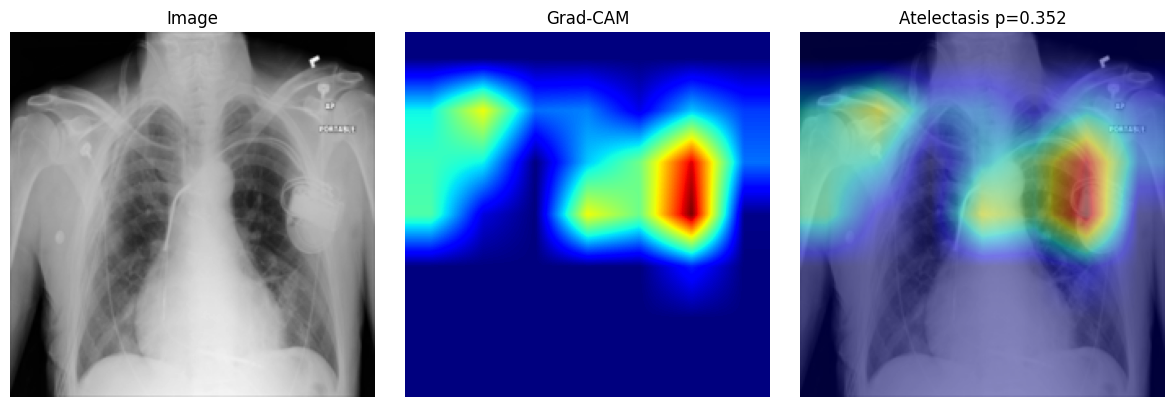

In [16]:
example = candidates[0]
image, heatmap, probability = run_gradcam_for_candidate(example)

print(example)
print("probability:", probability)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Image")
axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Grad-CAM")
axes[2].imshow(image, cmap="gray")
axes[2].imshow(heatmap, cmap="jet", alpha=0.45)
axes[2].set_title(f"{example['label']} p={probability:.3f}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 6. Generate Grad-CAM Figures

This saves figures under `outputs/interpretability/densenet121_pretrained_focal_gradcam/examples`.

In [17]:
records = []
examples_dir = OUTPUT_DIR / "examples"
examples_dir.mkdir(parents=True, exist_ok=True)

for idx, candidate in enumerate(candidates):
    image, heatmap, probability = run_gradcam_for_candidate(candidate)
    label = candidate["label"]
    image_name = candidate["image_name"]
    output_path = examples_dir / f"{idx:03d}_{Path(image_name).stem}_{label}_p{probability:.3f}.png"
    title = f"{image_name} | {label} | p={probability:.3f}"
    save_gradcam_figure(image, heatmap, output_path, title=title)
    records.append({
        "image_name": image_name,
        "image_path": candidate["image_path"],
        "label": label,
        "probability": probability,
        "figure_path": str(output_path),
    })

records_df = pd.DataFrame(records)
records_path = OUTPUT_DIR / "gradcam_examples.csv"
records_df.to_csv(records_path, index=False)
print("saved examples:", len(records_df))
print("records:", records_path)
display(records_df)


saved examples: 18
records: outputs/interpretability/densenet121_pretrained_focal_gradcam/gradcam_examples.csv


,image_name,image_path,label,probability,figure_path
0,00000013_030.png,/root/data/raw/images-224/images-224/00000013_...,Atelectasis,0.352448,outputs/interpretability/densenet121_pretraine...
1,00000013_035.png,/root/data/raw/images-224/images-224/00000013_...,Atelectasis,0.325831,outputs/interpretability/densenet121_pretraine...
2,00000013_025.png,/root/data/raw/images-224/images-224/00000013_...,Cardiomegaly,0.416269,outputs/interpretability/densenet121_pretraine...
3,00000013_026.png,/root/data/raw/images-224/images-224/00000013_...,Cardiomegaly,0.251155,outputs/interpretability/densenet121_pretraine...
4,00000013_004.png,/root/data/raw/images-224/images-224/00000013_...,Effusion,0.343686,outputs/interpretability/densenet121_pretraine...
5,00000013_006.png,/root/data/raw/images-224/images-224/00000013_...,Effusion,0.406342,outputs/interpretability/densenet121_pretraine...
6,00000013_022.png,/root/data/raw/images-224/images-224/00000013_...,Mass,0.509359,outputs/interpretability/densenet121_pretraine...
7,00000013_023.png,/root/data/raw/images-224/images-224/00000013_...,Mass,0.367535,outputs/interpretability/densenet121_pretraine...
8,00000013_025.png,/root/data/raw/images-224/images-224/00000013_...,Nodule,0.411008,outputs/interpretability/densenet121_pretraine...
9,00000032_041.png,/root/data/raw/images-224/images-224/00000032_...,Nodule,0.418538,outputs/interpretability/densenet121_pretraine...


## 7. Optional: BBox IoU Evaluation

NIH bbox annotations only cover a small subset of images and labels. This section computes a rough IoU between thresholded Grad-CAM heatmaps and bbox masks for overlapping test examples.

In [18]:
BBOX_CSV = Path("../data/annotations/BBox_list_2017.csv")
HEATMAP_THRESHOLD = 0.80
MAX_BBOX_EXAMPLES = 100
bbox_pairs = pd.DataFrame()

if not BBOX_CSV.exists():
    print("Missing bbox CSV:", BBOX_CSV)
else:
    bbox_df = load_bbox_annotations(BBOX_CSV)
    merged = bbox_df.merge(test_df[["image_name", "image_path"]], on="image_name", how="inner")
    bbox_pairs = merged.groupby(["image_name", "label", "image_path"], as_index=False).agg(list)
    bbox_pairs = bbox_pairs.head(MAX_BBOX_EXAMPLES)
    print("bbox image-label pairs:", len(bbox_pairs))
    display(bbox_pairs.head())


bbox image-label pairs: 100


,image_name,label,image_path,x,y,w,h
0,00000032_037.png,Infiltrate,/root/data/raw/images-224/images-224/00000032_...,[339.166137566138],[119.195767195767],[172.292063492064],[351.085714285714]
1,00000072_000.png,Atelectasis,/root/data/raw/images-224/images-224/00000072_...,[356.503703703704],[567.805291005291],[127.86455026455],[82.3534391534392]
2,00000147_001.png,Atelectasis,/root/data/raw/images-224/images-224/00000147_...,[617.650793650794],[599.22962962963],[100.774603174603],[179.877248677249]
3,00000149_006.png,Atelectasis,/root/data/raw/images-224/images-224/00000149_...,[603.661016949153],[460.239555746822],[249.491525423729],[90.0338983050847]
4,00000150_002.png,Pneumonia,/root/data/raw/images-224/images-224/00000150_...,[601.396825396825],[595.978835978836],[215.635978835979],[180.960846560847]


In [19]:
import matplotlib.patches as patches


def draw_boxes(axis, boxes, scale_x=1.0, scale_y=1.0, color="lime"):
    for _, box in boxes.iterrows():
        rect = patches.Rectangle(
            (float(box["x"]) * scale_x, float(box["y"]) * scale_y),
            float(box["w"]) * scale_x,
            float(box["h"]) * scale_y,
            linewidth=2.0,
            edgecolor=color,
            facecolor="none",
        )
        axis.add_patch(rect)


def save_bbox_comparison_figure(image, heatmap_resized, boxes, output_path, title):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Original + BBox")
    draw_boxes(axes[0], boxes)

    axes[1].imshow(image, cmap="gray")
    axes[1].imshow(heatmap_resized, cmap="jet", alpha=0.45)
    axes[1].set_title("DenseNet Grad-CAM + BBox")
    draw_boxes(axes[1], boxes)

    axes[2].imshow(heatmap_resized, cmap="jet")
    axes[2].set_title("Grad-CAM")

    for ax in axes:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=160)
    plt.close(fig)


bbox_records = []
bbox_examples_dir = OUTPUT_DIR / "bbox_examples"
bbox_examples_dir.mkdir(parents=True, exist_ok=True)

if BBOX_CSV.exists() and len(bbox_pairs) > 0:
    for idx, row in bbox_pairs.iterrows():
        label = str(row["label"])
        if label not in NIH_CHEST_XRAY_LABELS:
            continue
        candidate = {"image_name": row["image_name"], "image_path": row["image_path"], "label": label}
        image, heatmap, probability = run_gradcam_for_candidate(candidate)
        original_width, original_height = image.size
        heatmap_resized = np.array(
            Image.fromarray((heatmap * 255).astype(np.uint8)).resize((original_width, original_height))
        ) / 255.0
        pred_mask = (heatmap_resized >= HEATMAP_THRESHOLD).astype(np.uint8)
        boxes = pd.DataFrame({"x": row["x"], "y": row["y"], "w": row["w"], "h": row["h"]})
        gt_mask = build_ground_truth_mask(boxes, original_width, original_height)
        iou = compute_iou(pred_mask, gt_mask)
        output_path = bbox_examples_dir / f"{idx:03d}_{Path(row['image_name']).stem}_{label}_iou{iou:.3f}.png"
        title = f"{row['image_name']} | {label} | p={probability:.3f} | IoU={iou:.3f}"
        save_bbox_comparison_figure(image, heatmap_resized, boxes, output_path, title)
        bbox_records.append({
            "image_name": row["image_name"],
            "image_path": row["image_path"],
            "label": label,
            "probability": probability,
            "iou": iou,
            "figure_path": str(output_path),
        })

bbox_records_df = pd.DataFrame(bbox_records)
bbox_records_path = OUTPUT_DIR / "bbox_iou_records.csv"
bbox_records_df.to_csv(bbox_records_path, index=False)
print("bbox evaluated examples:", len(bbox_records_df))
if len(bbox_records_df):
    print("mean IoU:", bbox_records_df["iou"].mean())
    display(bbox_records_df.sort_values("iou", ascending=False).head(20))


bbox evaluated examples: 91
mean IoU: 0.0


,image_name,image_path,label,probability,iou,figure_path
0,00000072_000.png,/root/data/raw/images-224/images-224/00000072_...,Atelectasis,0.217627,0.0,outputs/interpretability/densenet121_pretraine...
1,00000147_001.png,/root/data/raw/images-224/images-224/00000147_...,Atelectasis,0.616023,0.0,outputs/interpretability/densenet121_pretraine...
2,00000149_006.png,/root/data/raw/images-224/images-224/00000149_...,Atelectasis,0.449726,0.0,outputs/interpretability/densenet121_pretraine...
3,00000150_002.png,/root/data/raw/images-224/images-224/00000150_...,Pneumonia,0.318914,0.0,outputs/interpretability/densenet121_pretraine...
4,00000181_061.png,/root/data/raw/images-224/images-224/00000181_...,Atelectasis,0.426761,0.0,outputs/interpretability/densenet121_pretraine...
5,00000193_019.png,/root/data/raw/images-224/images-224/00000193_...,Pneumonia,0.355963,0.0,outputs/interpretability/densenet121_pretraine...
6,00000211_010.png,/root/data/raw/images-224/images-224/00000211_...,Atelectasis,0.365106,0.0,outputs/interpretability/densenet121_pretraine...
7,00000211_019.png,/root/data/raw/images-224/images-224/00000211_...,Cardiomegaly,0.554724,0.0,outputs/interpretability/densenet121_pretraine...
8,00000211_041.png,/root/data/raw/images-224/images-224/00000211_...,Cardiomegaly,0.544262,0.0,outputs/interpretability/densenet121_pretraine...
9,00000344_003.png,/root/data/raw/images-224/images-224/00000344_...,Effusion,0.668714,0.0,outputs/interpretability/densenet121_pretraine...


## 8. Per-label Average Heatmap

This computes the average DenseNet Grad-CAM heatmap for each selected disease label using positive test examples. It is useful for report-level qualitative analysis: the average heatmap shows where the CNN tends to focus for each label across multiple images.

This is not a clinical localization metric. It is a qualitative summary and should be interpreted together with individual examples and bbox IoU.

saved per-label average heatmaps: 9


,label,num_examples,mean_probability,figure_path,array_path
0,Atelectasis,50,0.444718,outputs/interpretability/densenet121_pretraine...,outputs/interpretability/densenet121_pretraine...
1,Cardiomegaly,50,0.439715,outputs/interpretability/densenet121_pretraine...,outputs/interpretability/densenet121_pretraine...
2,Effusion,50,0.532490,outputs/interpretability/densenet121_pretraine...,outputs/interpretability/densenet121_pretraine...
3,Mass,50,0.432482,outputs/interpretability/densenet121_pretraine...,outputs/interpretability/densenet121_pretraine...
4,Nodule,50,0.410370,outputs/interpretability/densenet121_pretraine...,outputs/interpretability/densenet121_pretraine...
5,Pneumonia,50,0.311667,outputs/interpretability/densenet121_pretraine...,outputs/interpretability/densenet121_pretraine...
6,Pneumothorax,50,0.453617,outputs/interpretability/densenet121_pretraine...,outputs/interpretability/densenet121_pretraine...
7,Consolidation,50,0.460953,outputs/interpretability/densenet121_pretraine...,outputs/interpretability/densenet121_pretraine...
8,Edema,50,0.493669,outputs/interpretability/densenet121_pretraine...,outputs/interpretability/densenet121_pretraine...


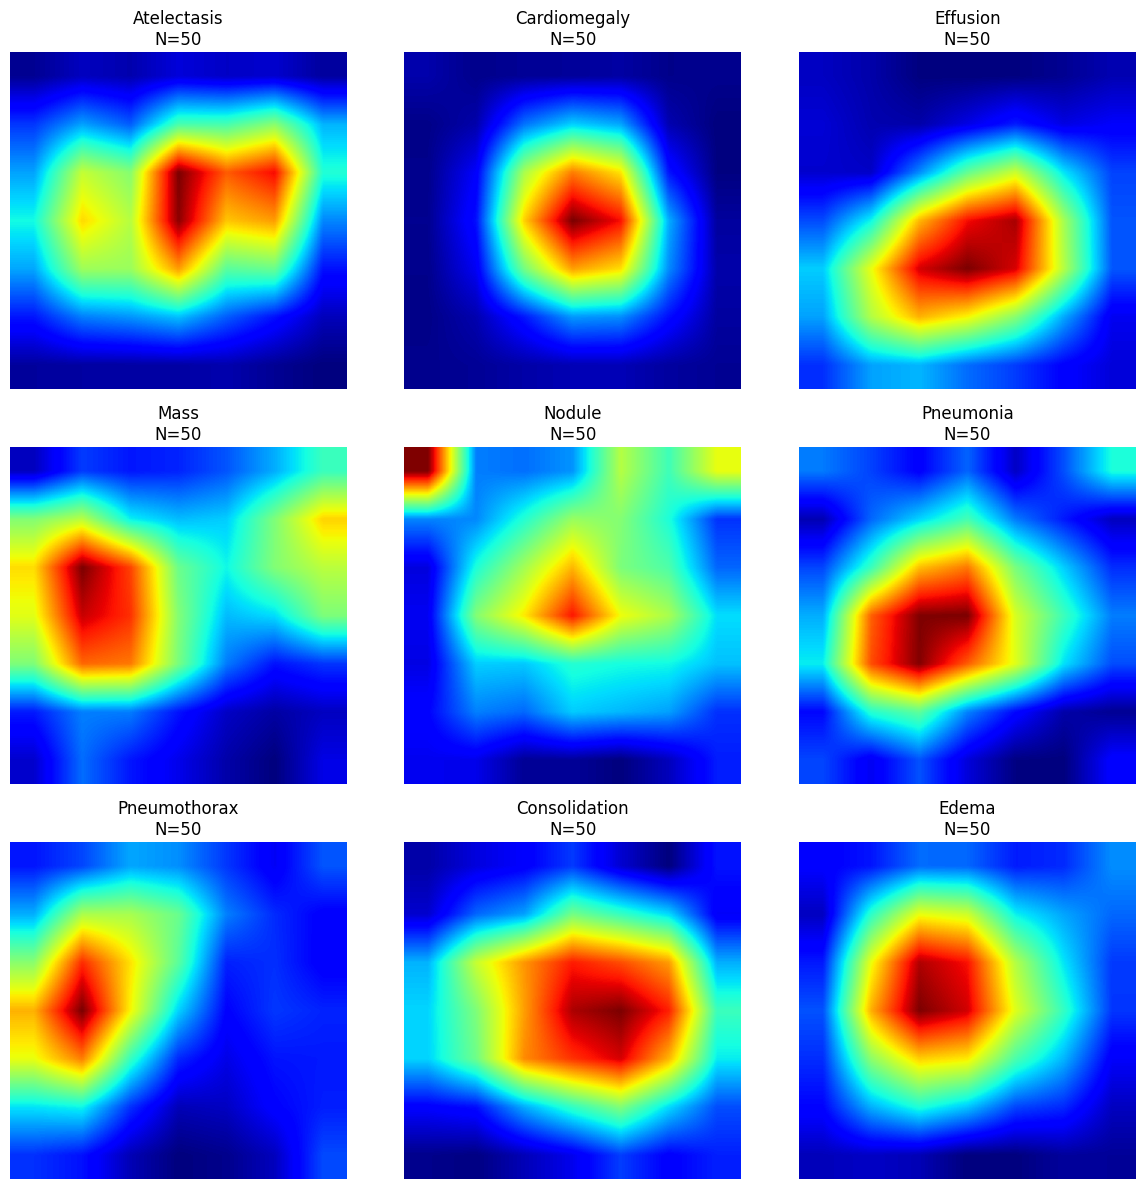

grid: outputs/interpretability/densenet121_pretrained_focal_gradcam/per_label_average_heatmaps/per_label_average_heatmaps_grid.png


In [20]:
AVG_LABELS = PRIORITY_LABELS
MAX_AVG_PER_LABEL = 50
avg_dir = OUTPUT_DIR / "per_label_average_heatmaps"
avg_dir.mkdir(parents=True, exist_ok=True)

avg_records = []
for label in AVG_LABELS:
    if label not in test_df.columns:
        continue
    positives = test_df[test_df[label] == 1].head(MAX_AVG_PER_LABEL)
    if positives.empty:
        print(f"skip {label}: no positives")
        continue

    heatmaps = []
    probabilities = []
    for _, row in positives.iterrows():
        candidate = {"image_name": row["image_name"], "image_path": row["image_path"], "label": label}
        image, heatmap, probability = run_gradcam_for_candidate(candidate)
        heatmaps.append(heatmap.astype(np.float32))
        probabilities.append(probability)

    avg_heatmap = np.mean(np.stack(heatmaps, axis=0), axis=0)
    avg_heatmap = (avg_heatmap - avg_heatmap.min()) / (avg_heatmap.max() - avg_heatmap.min() + 1e-8)

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(avg_heatmap, cmap="jet")
    ax.set_title(f"{label}\nN={len(heatmaps)}, mean p={np.mean(probabilities):.3f}")
    ax.axis("off")
    fig.tight_layout()
    output_path = avg_dir / f"avg_gradcam_{label}.png"
    fig.savefig(output_path, dpi=160)
    plt.close(fig)

    np.save(avg_dir / f"avg_gradcam_{label}.npy", avg_heatmap)
    avg_records.append({
        "label": label,
        "num_examples": len(heatmaps),
        "mean_probability": float(np.mean(probabilities)),
        "figure_path": str(output_path),
        "array_path": str(avg_dir / f"avg_gradcam_{label}.npy"),
    })

avg_records_df = pd.DataFrame(avg_records)
avg_records_path = avg_dir / "per_label_average_heatmaps.csv"
avg_records_df.to_csv(avg_records_path, index=False)
print("saved per-label average heatmaps:", len(avg_records_df))
display(avg_records_df)

# Display a compact grid in the notebook.
if len(avg_records_df):
    ncols = 3
    nrows = int(np.ceil(len(avg_records_df) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, avg_records_df.iterrows()):
        heatmap = np.load(row["array_path"])
        ax.imshow(heatmap, cmap="jet")
        ax.set_title(f"{row['label']}\nN={row['num_examples']}")
        ax.axis("off")
    for ax in axes[len(avg_records_df):]:
        ax.axis("off")
    fig.tight_layout()
    grid_path = avg_dir / "per_label_average_heatmaps_grid.png"
    fig.savefig(grid_path, dpi=160)
    plt.show()
    print("grid:", grid_path)


## 9. Cleanup Hooks


In [21]:
grad_cam.remove_hooks()
print("Grad-CAM hooks removed.")


Grad-CAM hooks removed.
